# Introduction
The following four topics will be discussed

- Financial Data
  -  data import
  -  summary statistics
  -  resampling
-  Rolling Statistics
  -  moving average
  
- Correlation Analysis
  - S&P 500 index and Vix relationship
  
- High Frequency data

## Rolling statistics 

- financial data: daily 
  - High Frequency: tick by tick (1year: >100Million line )
- macro: monthly/quarterly 
- How to align? 
- Question: 
  - daily data --> weekly or monthly data conversion? 
  - rolling statics 
    - DON'T USE AVERAGE 
    - (average daily data over the last week (M-F))

## Data import from web: <font color='yellow'>Here yahoo finance</font>

In [3]:
import pandas as pd  # financial data; enough
import numpy as np
import matplotlib.pyplot as plt
pd.core.common.is_list_like = pd.api.types.is_list_like
from pandas_datareader import data as pdr
import yfinance as yf
# if wish to override hassle with pandas then use yf.download()
# KRX: pykrx 
# News: NewsAPI, Alphavantage, EXA (mcp server)

## Data import: from yahoo finance

In [ ]:
# tickers


In [1]:
tickers = ['AAPL', 'MSFT', 'IBM', 'GOOG', "TSLA", "^GSPC", "^IXIC", "^VIX", "^GSPC", "BTC-USD", "ETH-USD", "XRP-USD", "BTC-USD", "ETH-USD", "ETH-USD", "^KS11", "^VIX"]
# ^GSPC: S&P 500 index
# ^IXIC: NASDAQ index
# ^VIX: Vix index
# ^KS11: KOSPI index
# PLTR(BTC), BIMR(Ethereum)

# US financial market turmoil 
## shut-down, 장단기금리 역전


In [4]:
ticker = tickers[0]
aapl = yf.download('AAPL', "2020-01-01")

/tmp/ipykernel_1001673/733384583.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  aapl = yf.download('AAPL', "2020-01-01")
[*********************100%***********************]  1 of 1 completed


In [5]:
aapl.columns = [x[0].lower() for x in aapl.columns]
aapl.head()

,close,high,low,open,volume
Date,,,,,
2020-01-02,72.538521,72.598899,71.292311,71.545897,135480400
2020-01-03,71.833298,72.594063,71.608692,71.765674,146322800
2020-01-06,72.405670,72.444313,70.703005,70.954181,118387200
2020-01-07,72.065140,72.671333,71.845362,72.415330,108872000
2020-01-08,73.224380,73.526272,71.768056,71.768056,132079200


# Volume 
- is volume useful in equity market? 
- "today volume >> MA(volume, 5 or 20 or 50): new information 
- volume: change hands 
  - if information comes in financial market, market participants pricing differently ---> CHANGE HANDS
- PRIVATE INFORMATION PROXY 
  - only me, useful to predict price 
- USE as Features in MLearning or DeepLearning 

## Data export as 'csv' file

In [ ]:
#aapl.to_csv("aapl.csv")
# df = pd.read_csv("aapl.csv")
# df.index = pd.to_datetime(df.index)

## Data import from csv file

In [ ]:
# import

#AAPL = pd.read_csv("c:/python/data/pff/AAPL.csv")

In [6]:
df = pd.DataFrame()
for ticker in tickers:
    tmp = yf.download(ticker, "2020-01-01")['Close']
    tmp.columns =[x.lower() for x in tmp.columns]
    df[ticker]=tmp


/tmp/ipykernel_1001673/1601371160.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tmp = yf.download(ticker, "2020-01-01")['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1001673/1601371160.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tmp = yf.download(ticker, "2020-01-01")['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1001673/1601371160.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tmp = yf.download(ticker, "2020-01-01")['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1001673/1601371160.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tmp = yf.download(ticker, "2020-01-01")['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1001673/1601371160.py:3: FutureWa

In [7]:
df.head()

,AAPL,MSFT,IBM,GOOG,TSLA,^GSPC,^IXIC,^VIX,BTC-USD,ETH-USD,XRP-USD,^KS11
Date,,,,,,,,,,,,
2020-01-02,72.538521,152.791122,100.565201,67.903809,28.684000,3257.850098,9092.190430,12.47,6985.470215,127.410179,0.188043,2175.169922
2020-01-03,71.833282,150.888580,99.763168,67.570595,29.534000,3234.850098,9020.769531,14.02,7344.884277,134.171707,0.193521,2176.459961
2020-01-06,72.405678,151.278641,99.584953,69.236702,30.102667,3246.280029,9071.469727,13.85,7769.219238,144.304153,0.221510,2155.070068
2020-01-07,72.065155,149.899292,99.651764,69.193489,31.270666,3237.179932,9068.580078,13.79,8163.692383,143.543991,0.213917,2175.540039
2020-01-08,73.224403,152.286957,100.483490,69.738754,32.809334,3253.050049,9129.240234,13.45,8079.862793,141.258133,0.209026,2151.310059


In [8]:
print(df.tail())

                  AAPL        MSFT         IBM        GOOG        TSLA  \
Date                                                                     
2025-09-24  252.309998  510.149994  267.529999  247.830002  442.790009   
2025-09-25  256.869995  507.029999  281.440002  246.570007  423.390015   
2025-09-26  255.460007  511.459991  284.309998  247.179993  440.399994   
2025-09-29  254.429993  514.599976  279.799988  244.360001  443.209991   
2025-09-30  254.630005  517.950012  282.160004  243.550003  444.720001   

                  ^GSPC         ^IXIC       ^VIX        BTC-USD      ETH-USD  \
Date                                                                           
2025-09-24  6637.970215  22497.859375  16.180000  113328.632812  4153.469238   
2025-09-25  6604.720215  22384.699219  16.740000  109049.289062  3868.333984   
2025-09-26  6643.700195  22484.070312  15.290000  109712.828125  4035.887939   
2025-09-29  6661.209961  22591.150391  16.120001  114400.382812  4217.341797   
2

In [ ]:
# save for later use

df.to_csv("your_directory")
df = pd.read_csv("your_directory")
df.index = pd.to_datetime(df.index)
df.head()
# Preliminary Analysis

# Preliminary Analysis


## Basic Statistics

In [ ]:
# basic statistics
df.describe()
# 2025-09-30 before/after: short-term bond, cloud/blockchain, 

,AAPL,MSFT,IBM,GOOG,TSLA,^GSPC,^IXIC,^VIX,BTC-USD,ETH-USD,XRP-USD,^KS11
count,1444.000000,1444.000000,1444.000000,1444.000000,1444.000000,1444.000000,1444.000000,1444.000000,1444.000000,1444.000000,1444.000000,1364.000000
mean,160.514211,308.548523,143.438342,127.763390,228.094549,4486.868158,14201.038155,21.149765,44846.382140,2106.108055,0.834906,2627.363379
std,45.674783,95.583998,53.296237,39.012280,88.885166,938.285703,3294.222794,8.023443,29930.725798,1165.106988,0.763757,348.008502
min,54.316929,129.171265,71.112717,52.471924,24.081333,2237.399902,6860.669922,11.860000,4970.788086,110.605873,0.139635,1457.640015
25%,130.447460,235.046608,107.698198,98.274981,180.517494,3892.050049,11693.974854,15.927500,21237.729492,1375.232056,0.381452,2417.529968
50%,160.930786,290.050018,119.391338,128.546555,231.901672,4356.745117,13780.280273,19.195001,38309.318359,1961.298218,0.537158,2582.189941
75%,191.020981,398.621284,173.759525,154.698856,282.279991,5182.137695,16249.879639,24.352500,61733.762695,2987.652649,0.852490,2826.835083
max,258.103729,534.760925,292.800354,255.240005,479.859985,6693.750000,22788.980469,82.690002,123344.062500,4831.348633,3.555765,3486.189941


<Axes: xlabel='Date'>

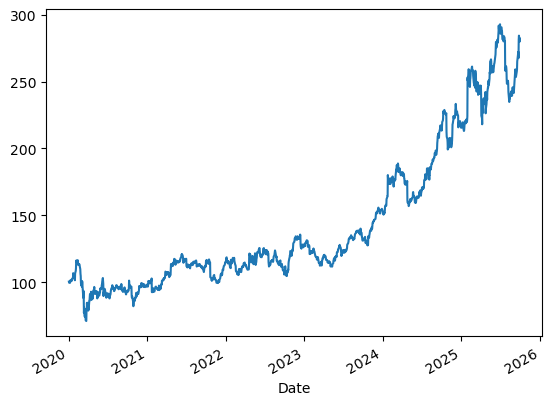

In [13]:
df['IBM'].plot()

In [ ]:
df.quantile(q=0.5)  # median 

AAPL         160.930786
MSFT         290.050018
IBM          119.391338
GOOG         128.546555
TSLA         231.901672
^GSPC       4356.745117
^IXIC      13780.280273
^VIX          19.195001
BTC-USD    38309.318359
ETH-USD     1961.298218
XRP-USD        0.537158
^KS11       2582.189941
Name: 0.5, dtype: float64

## Plotting

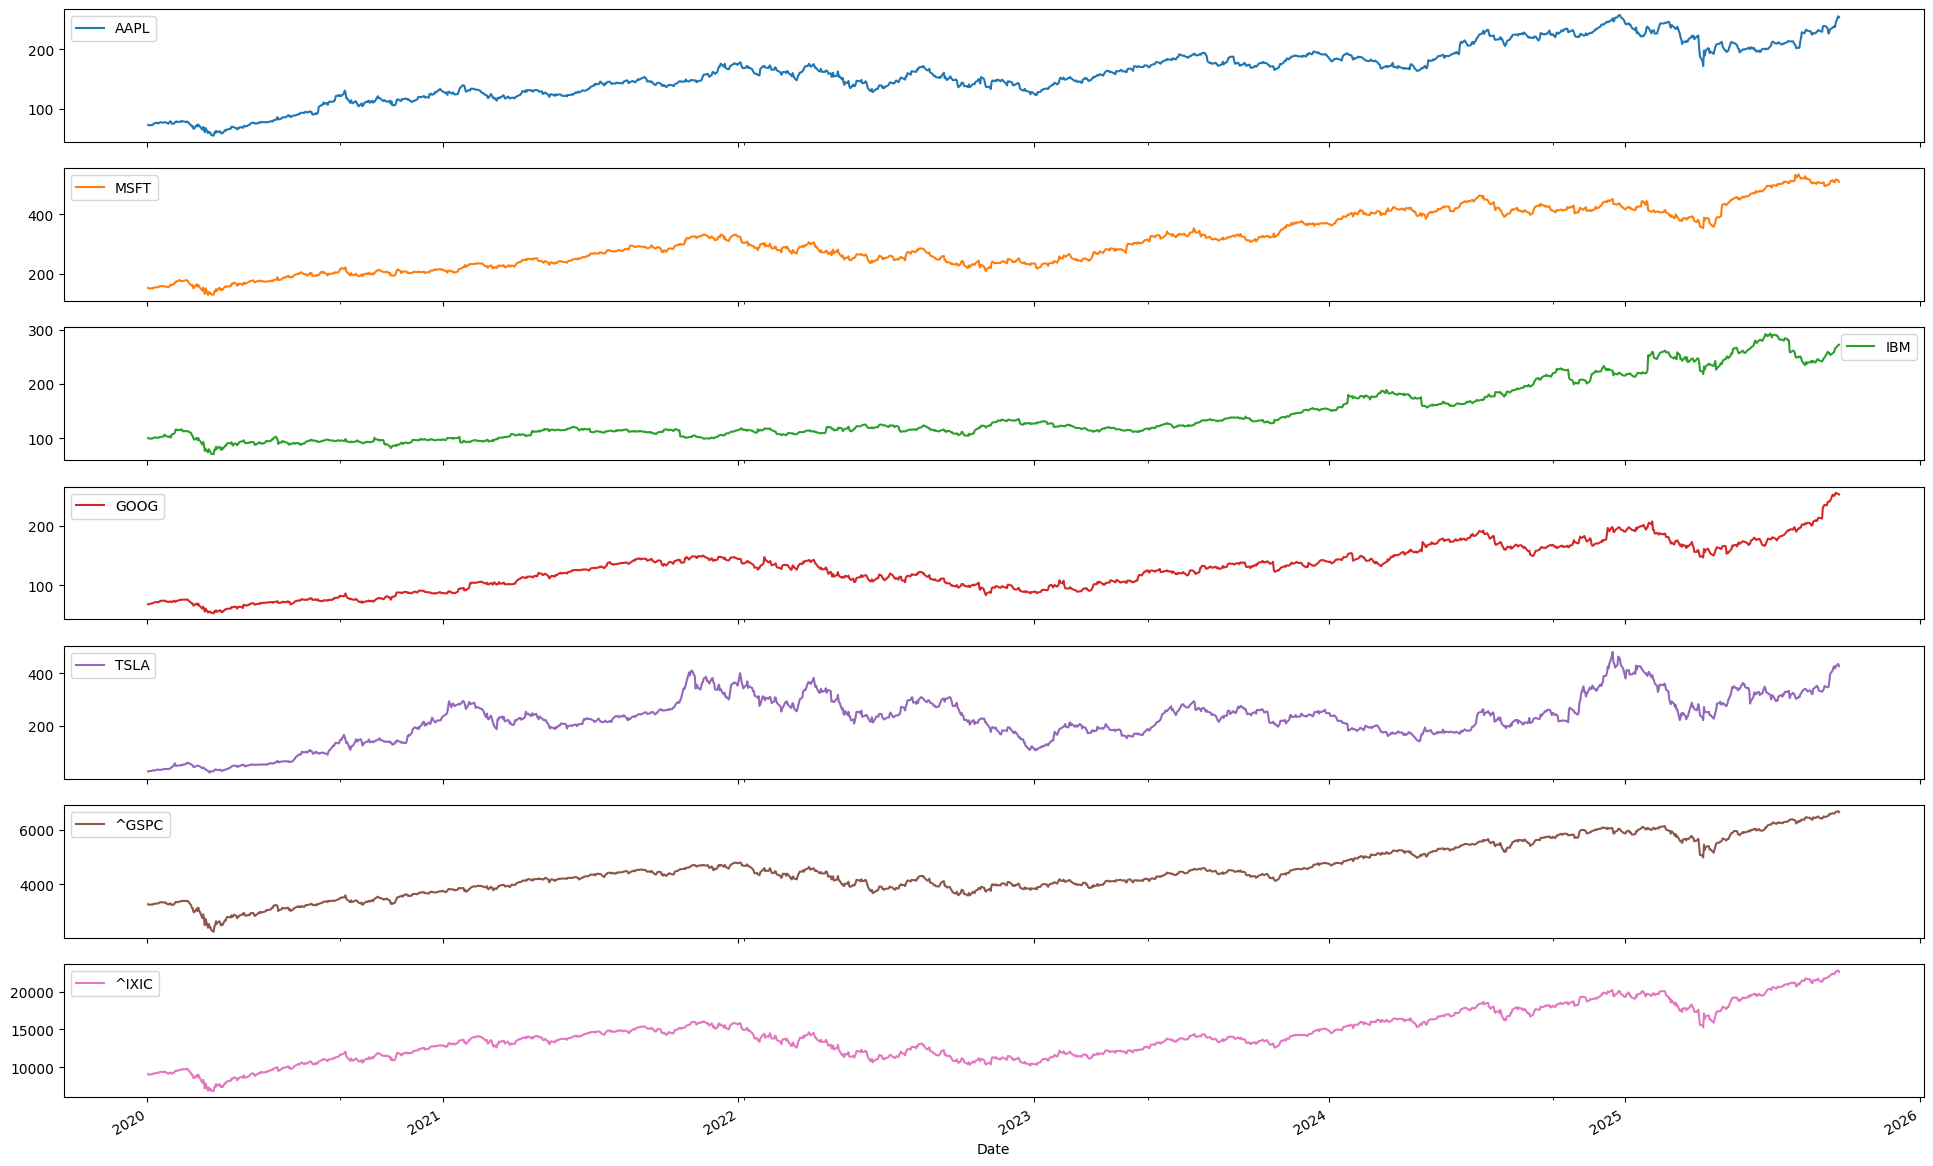

In [ ]:
#data_close.plot()
df.plot(subplots=True, figsize=(24,16))
plt.show()

## Rate of return related

In [15]:
# percentage return

df.pct_change().dropna().head()

/tmp/ipykernel_1001673/1253659673.py:3: FutureWarning:

The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.



,AAPL,MSFT,IBM,GOOG,TSLA,^GSPC,^IXIC,^VIX,BTC-USD,ETH-USD,XRP-USD,^KS11
Date,,,,,,,,,,,,
2020-01-03,-0.009722,-0.012452,-0.007975,-0.004907,0.029633,-0.007060,-0.007855,0.124298,0.051452,0.053069,0.029132,0.000593
2020-01-06,0.007968,0.002585,-0.001786,0.024657,0.019255,0.003533,0.005620,-0.012126,0.057773,0.075519,0.144630,-0.009828
2020-01-07,-0.004703,-0.009118,0.000671,-0.000624,0.038801,-0.002803,-0.000319,-0.004332,0.050774,-0.005268,-0.034278,0.009499
2020-01-08,0.016086,0.015928,0.008346,0.007880,0.049205,0.004902,0.006689,-0.024656,-0.010269,-0.015924,-0.022864,-0.011137
2020-01-09,0.021241,0.012493,0.010568,0.011045,-0.021945,0.006655,0.008127,-0.067658,-0.024851,-0.016133,-0.019744,0.016334


In [16]:
# log return

np.log(df/df.shift(1)).dropna().head()

,AAPL,MSFT,IBM,GOOG,TSLA,^GSPC,^IXIC,^VIX,BTC-USD,ETH-USD,XRP-USD,^KS11
Date,,,,,,,,,,,,
2020-01-03,-0.009770,-0.012530,-0.008007,-0.004919,0.029203,-0.007085,-0.007886,0.117159,0.050172,0.051709,0.028715,0.000593
2020-01-06,0.007937,0.002582,-0.001788,0.024358,0.019072,0.003527,0.005605,-0.012200,0.056166,0.072803,0.135082,-0.009876
2020-01-07,-0.004714,-0.009160,0.000671,-0.000624,0.038067,-0.002807,-0.000319,-0.004342,0.049527,-0.005282,-0.034880,0.009454
2020-01-08,0.015958,0.015803,0.008312,0.007849,0.048033,0.004890,0.006667,-0.024965,-0.010322,-0.016053,-0.023129,-0.011200
2020-01-09,0.021019,0.012416,0.010513,0.010984,-0.022189,0.006633,0.008094,-0.070056,-0.025165,-0.016265,-0.019941,0.016202


In [ ]:
# differnce

df.diff().dropna().head()

,AAPL,MSFT,IBM,GOOG,TSLA,^GSPC,^IXIC
Date,,,,,,,
2020-01-03,-0.705246,-1.902573,-0.802017,-0.333237,0.850000,-23.000000,-71.420898
2020-01-06,0.572388,0.390060,-0.178207,1.666107,0.568666,11.429932,50.700195
2020-01-07,-0.340530,-1.379318,0.066811,-0.043198,1.167999,-9.100098,-2.889648
2020-01-08,1.159271,2.387634,0.831749,0.545265,1.538668,15.870117,60.660156
2020-01-09,1.555344,1.902527,1.061913,0.770233,-0.720001,21.649902,74.189453


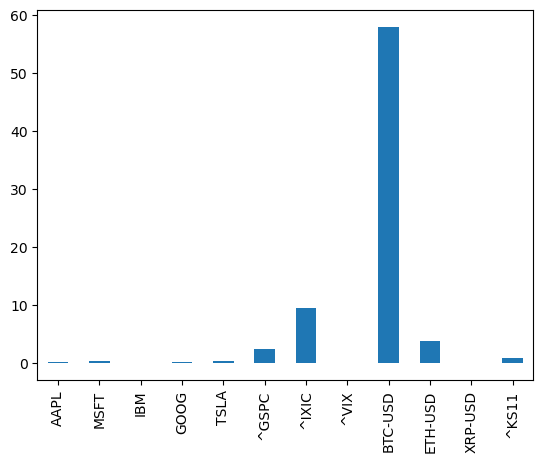

In [17]:
# plot difference mean histogram

df.diff().dropna().mean().plot(kind='bar');

/tmp/ipykernel_1001673/3208691241.py:1: FutureWarning:

The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.



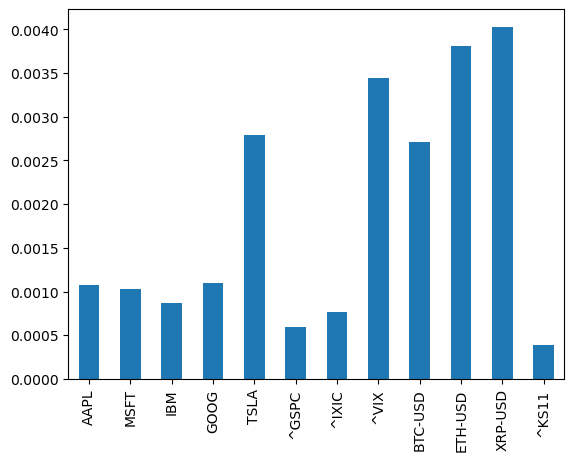

In [18]:
df.pct_change().dropna().mean().plot(kind='bar');

<Axes: xlabel='Date'>

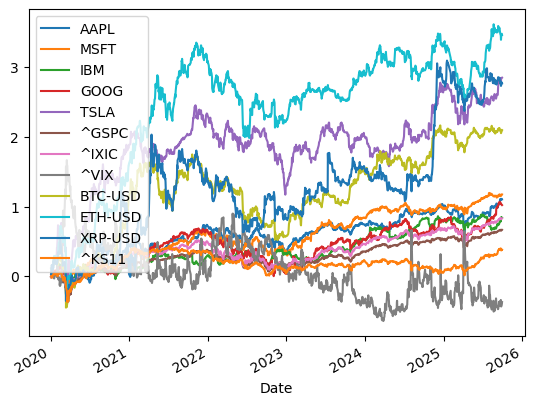

In [19]:
ret = np.log(df/df.shift(1)).dropna()
ret.cumsum().plot()

<Axes: xlabel='Date'>

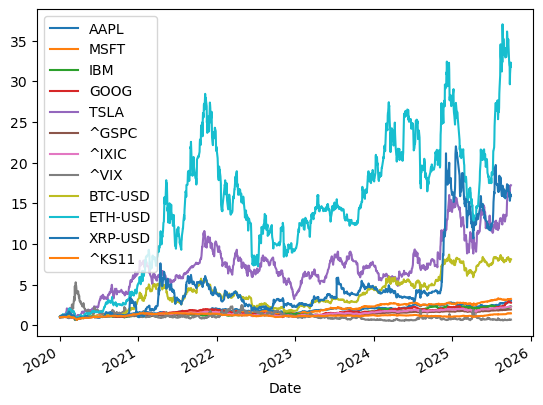

In [20]:
ret.cumsum().apply(np.exp).plot()   # why exp?

**Cumulative return**
\begin{align*}
\exp\left[log \left(\ 1+ \frac{p_t - p_{t-1}}{p_{t-1}}    \right).cumsum  \right] -1
\end{align*}  

<Axes: xlabel='Date'>

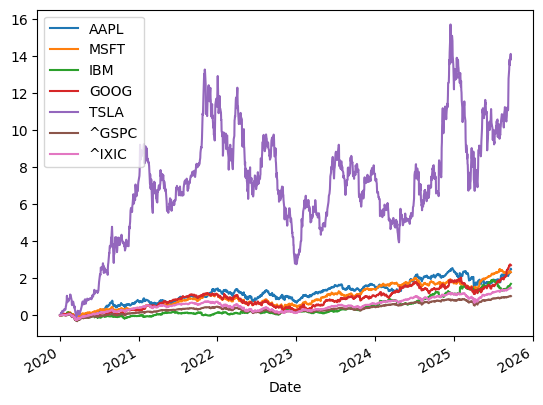

In [ ]:
ret = df.pct_change()
cum_ret = np.exp(np.log(1+ret).cumsum())-1
cum_ret.plot()

# Resampling

In [ ]:
df.resample('1w', label='right').first().head()
# M-F: stick to it 

/tmp/ipykernel_1001673/750673998.py:1: FutureWarning:

'w' is deprecated and will be removed in a future version, please use 'W' instead.



,AAPL,MSFT,IBM,GOOG,TSLA,^GSPC,^IXIC,^VIX,BTC-USD,ETH-USD,XRP-USD,^KS11
Date,,,,,,,,,,,,
2020-01-05,72.538521,152.791122,100.565201,67.903809,28.684000,3257.850098,9092.190430,12.47,6985.470215,127.410179,0.188043,2175.169922
2020-01-12,72.405678,151.278641,99.584953,69.236702,30.102667,3246.280029,9071.469727,13.85,7769.219238,144.304153,0.221510,2155.070068
2020-01-19,76.550049,155.321457,101.441475,71.472397,34.990665,3288.129883,9273.929688,12.32,8144.194336,144.226593,0.212617,2229.260010
2020-01-26,76.455856,158.384537,103.350006,73.715538,36.480000,3320.790039,9370.809570,12.85,8745.894531,169.697159,0.237166,2239.689941
2020-02-02,74.615540,154.370224,102.941566,71.207703,37.201332,3243.629883,9139.309570,18.23,8909.819336,170.930893,0.231222,2176.719971


In [ ]:
df.resample('1w', label='right').last().head()

/tmp/ipython-input-1009130987.py:1: FutureWarning: 'w' is deprecated and will be removed in a future version, please use 'W' instead.
  df.resample('1w', label='right').last().head()


,AAPL,MSFT,IBM,GOOG,TSLA,^GSPC,^IXIC
Date,,,,,,,
2020-01-05,71.833282,150.888565,99.763168,67.570587,29.534000,3234.850098,9020.769531
2020-01-12,74.948830,153.476074,101.508316,71.000633,31.876667,3265.350098,9178.860352
2020-01-19,76.977524,158.955276,102.711365,73.516403,34.033333,3329.620117,9388.940430
2020-01-26,76.876091,156.995697,104.382240,72.837051,37.654667,3295.469971,9314.910156
2020-02-02,74.750801,161.932755,106.736320,71.224091,43.371334,3225.520020,9150.940430


In [ ]:
df.index.weekday
# business day 

Index([3, 4, 0, 1, 2, 3, 4, 0, 1, 2,
       ...
       2, 3, 4, 0, 1, 2, 3, 4, 0, 1],
      dtype='int32', name='Date', length=1444)

In [ ]:
df.resample('M', label='left', closed='left').last().head()

/tmp/ipython-input-4221010652.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.resample('M', label='left', closed='left').last().head()


,AAPL,MSFT,IBM,GOOG,TSLA,^GSPC,^IXIC
Date,,,,,,,
2019-12-31,78.218895,164.358414,101.567719,72.297256,42.720669,3283.659912,9298.929688
2020-01-31,66.176735,154.534332,97.660851,66.511345,44.532665,2954.219971,8567.370117
2020-02-29,61.686050,152.836395,84.739441,56.951267,33.475334,2626.649902,7774.149902
2020-03-31,69.655510,169.242767,96.565300,66.618118,53.367332,2939.510010,8914.709961
2020-04-30,77.177322,175.281067,94.978317,70.960403,55.666668,3044.310059,9489.870117


/tmp/ipython-input-1020566399.py:3: FutureWarning: 'm' is deprecated and will be removed in a future version, please use 'ME' instead.
  ax = ret.cumsum().resample('m').last().plot()


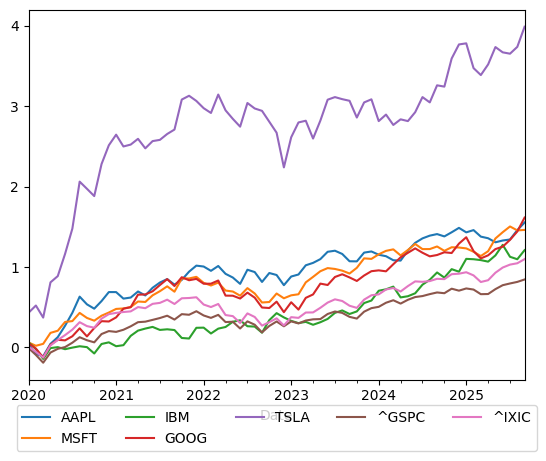

In [ ]:
#ret.index = pd.to_datetime(ret.index)

ax = ret.cumsum().resample('m').last().plot()
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=5)
#ax.legend(loc='center left')

#ret.cumsum().resample('m').last().plot(figsize=(16,9))

# Rolling Statistics

In [23]:
#df['min'] = df.rolling(window=20).min()
#df['max'] = df.rolling(window=20).max()
tsla_mean = df['TSLA'].rolling(20).mean()

<Axes: xlabel='Date'>

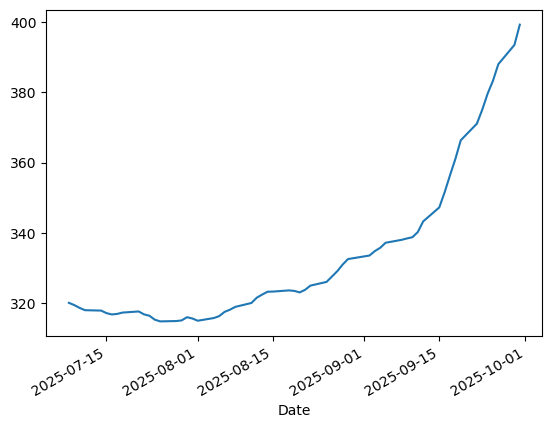

In [24]:
tsla_mean[-60:].plot()

In [ ]:
df2 = df['TSLA'].copy()
df2 = pd.DataFrame(df2)
df2.index =  pd.to_datetime(df.index)
df2.columns = ['close']
df2 = df2.dropna()

In [ ]:
df2.head()

,close,sma20
Date,,
2020-01-02,28.684000,NaN
2020-01-03,29.534000,NaN
2020-01-06,30.102667,NaN
2020-01-07,31.270666,NaN
2020-01-08,32.809334,NaN


In [ ]:
df2['sma20'] = df2['close'].rolling(20).mean()
df2['sma60'] = df2['close'].rolling(60).mean()

In [ ]:
df2['position'] = list(map(lambda x,y: [-1,1][x>y], df2['sma20'], df2['sma60']))
df2['position2'] = np.where(df2['sma20']>df2['sma60'], 1, -1)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

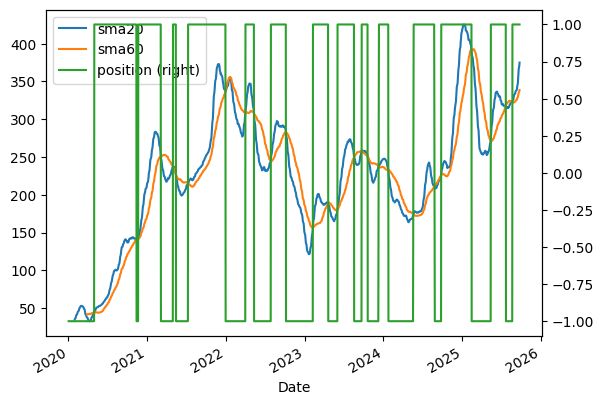

In [ ]:
%matplotlib inline
df2[['sma20', 'sma60', 'position']].plot(secondary_y = 'position')
plt.show()

# Correlation Analysis

In [25]:
vix = yf.download('^VIX', "2020-01-01")
vix = vix['Close']
vix.columns =['VIX']
df['VIX']= vix

/tmp/ipykernel_1001673/260240712.py:1: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


In [26]:
data_index = df[['^GSPC', 'VIX']]
data_index = data_index.dropna()
data_index.head()

,^GSPC,VIX
Date,,
2020-01-02,3257.850098,12.47
2020-01-03,3234.850098,14.02
2020-01-06,3246.280029,13.85
2020-01-07,3237.179932,13.79
2020-01-08,3253.050049,13.45


<Axes: xlabel='Date'>

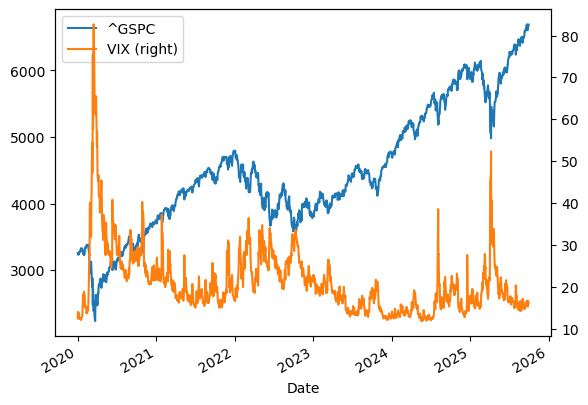

In [27]:
data_index.plot(secondary_y='VIX')

In [ ]:
ret_index = data_index.pct_change()
ret_index = ret_index.dropna()

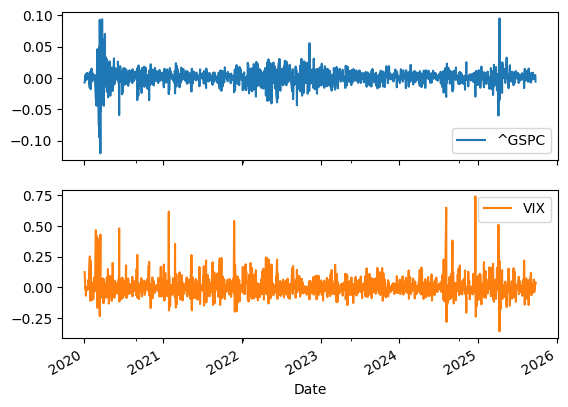

In [ ]:
%matplotlib inline

ret_index.plot(subplots=True);

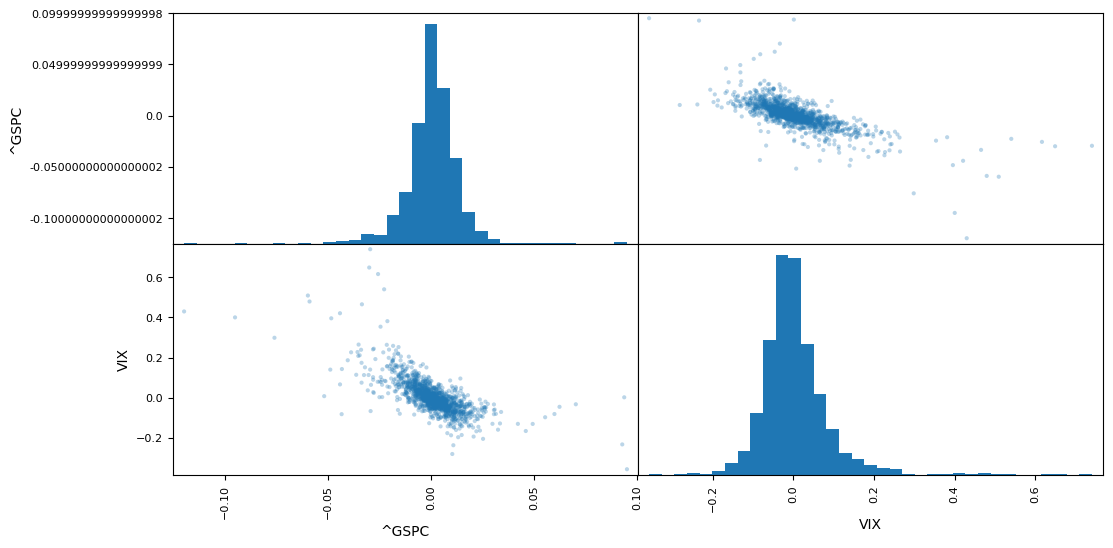

In [ ]:
pd.plotting.scatter_matrix(ret_index, diagonal='hist', figsize=(12,6), hist_kwds={'bins': 35}, alpha=0.3);

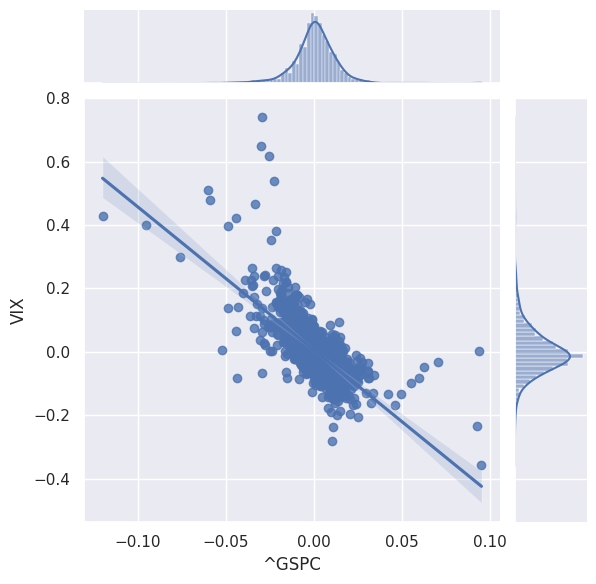

In [ ]:
import seaborn as sns;  sns.set()

sns.jointplot(x='^GSPC', y='VIX', data=ret_index, kind='reg')

In [ ]:
rets_corr = ret_index.corr()
rets_corr

,^GSPC,VIX
^GSPC,1.000000,-0.714464
VIX,-0.714464,1.000000


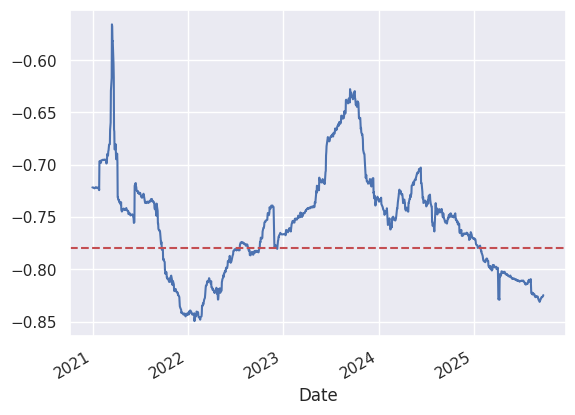

In [ ]:
ax= ret_index['^GSPC'].rolling(window=252).corr(ret_index['VIX']).plot()
#ax.axvline(rets_corr.iloc[0,1])
ax.axhline(y=-0.78, c='r', ls='--')